<a href="https://colab.research.google.com/github/Moi2204/Minh/blob/main/BTVN_b2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 12.5 MB/s eta 0:00:00


KLG đồ:5
độ bẩn ở cỡ nào:50
độ dày vải:90
TG giặt:93.75624850927068 phút
Mực nước cần dùng: 72.34984984984982 ml


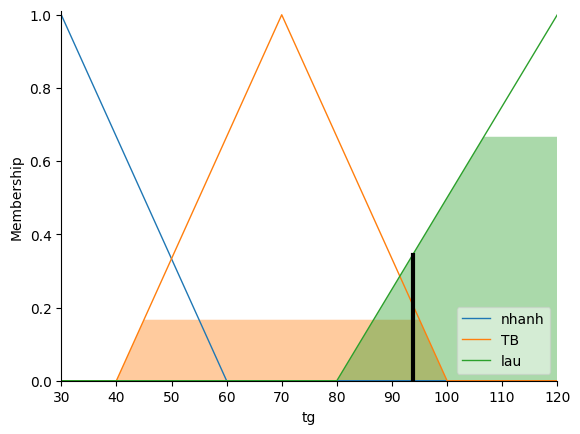

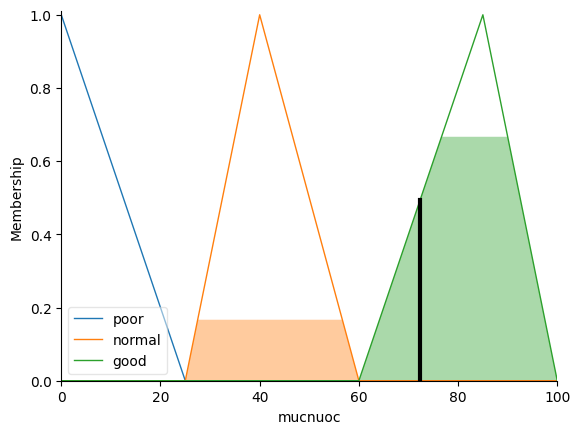

In [4]:
#máy giặt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
tair = ctrl.Antecedent(np.arange(0,12.1,0.1),'tair')
doban = ctrl.Antecedent(np.arange(0,100.1,0.1),'doban')
loaivai= ctrl.Antecedent(np.arange(0,100.1,0.1),'loaivai')
tg=ctrl.Consequent(np.arange(30,120.1,1),'tg')
mucnuoc=ctrl.Consequent(np.arange(0,100.1,0.1),'mucnuoc')

tair['nhe']=fuzz.trimf(tair.universe,[0,0,6])
tair['TB']=fuzz.trimf(tair.universe,[0,6,12])
tair['lon']=fuzz.trimf(tair.universe,[6,12,12])
doban['thap']=fuzz.trimf(doban.universe,[0,0,50])
doban['TB']=fuzz.trimf(doban.universe,[0,50,100])
doban['Cao']=fuzz.trimf(doban.universe,[50,100,100])
loaivai['mem'] = fuzz.trimf(loaivai.universe, [0, 0, 35])
loaivai['TB'] = fuzz.trimf(loaivai.universe, [35, 50, 70])
loaivai['day'] = fuzz.trimf(loaivai.universe, [70, 85, 100])
tg['nhanh']=fuzz.trimf(tg.universe,[30,30,60])
tg['TB']=fuzz.trimf(tg.universe,[40,70,100])
tg['lau']=fuzz.trimf(tg.universe,[80,120,120])
mucnuoc['poor']=fuzz.trimf(mucnuoc.universe,[0,0,25])
mucnuoc['normal']=fuzz.trimf(mucnuoc.universe,[25,40,60])
mucnuoc['good']=fuzz.trimf(mucnuoc.universe,[60,85,100])

rule1 = ctrl.Rule(tair['nhe'] & doban['thap'] & loaivai['mem'], [tg['nhanh'], mucnuoc['poor']])
rule2 = ctrl.Rule(tair['nhe'] & doban['thap'] & loaivai['TB'],  [tg['nhanh'],  mucnuoc['poor']])
rule3 = ctrl.Rule(tair['nhe'] & doban['thap'] & loaivai['day'], [tg['TB'],     mucnuoc['normal']])
rule4 = ctrl.Rule(tair['nhe'] & doban['TB']   & loaivai['mem'], [tg['nhanh'],  mucnuoc['poor']])
rule5 = ctrl.Rule(tair['nhe'] & doban['TB']   & loaivai['TB'],  [tg['TB']  ,   mucnuoc['normal']])
rule6 = ctrl.Rule(tair['nhe'] & doban['TB']   & loaivai['day'], [tg['TB']  ,   mucnuoc['normal']])
rule7 = ctrl.Rule(tair['nhe'] & doban['Cao']  & loaivai['mem'], [tg['TB']   ,  mucnuoc['normal']])
rule8 = ctrl.Rule(tair['nhe'] & doban['Cao']  & loaivai['TB'],  [tg['TB']   ,  mucnuoc['normal']])
rule9 = ctrl.Rule(tair['nhe'] & doban['Cao']  & loaivai['day'], [tg['lau']  ,  mucnuoc['good']])

rule10 = ctrl.Rule(tair['TB'] & doban['thap'] & loaivai['mem'], [tg['nhanh'] , mucnuoc['poor']])
rule11 = ctrl.Rule(tair['TB'] & doban['thap'] & loaivai['TB'],  [tg['TB']   ,  mucnuoc['normal']])
rule12 = ctrl.Rule(tair['TB'] & doban['thap'] & loaivai['day'], [tg['TB']   ,  mucnuoc['normal']])
rule13 = ctrl.Rule(tair['TB'] & doban['TB']   & loaivai['mem'], [tg['TB']   ,  mucnuoc['normal']])
rule14 = ctrl.Rule(tair['TB'] & doban['TB']   & loaivai['TB'],  [tg['TB']   ,  mucnuoc['normal']])
rule15 = ctrl.Rule(tair['TB'] & doban['TB']   & loaivai['day'], [tg['lau']  ,  mucnuoc['good']])
rule16 = ctrl.Rule(tair['TB'] & doban['Cao']  & loaivai['mem'], [tg['TB']   ,  mucnuoc['normal']])
rule17 = ctrl.Rule(tair['TB'] & doban['Cao']  & loaivai['TB'],  [tg['lau']  ,  mucnuoc['good']])
rule18 = ctrl.Rule(tair['TB'] & doban['Cao']  & loaivai['day'], [tg['lau']  ,  mucnuoc['good']])

rule19 = ctrl.Rule(tair['lon'] & doban['thap'] & loaivai['mem'], [tg['TB']  ,   mucnuoc['normal']])
rule20 = ctrl.Rule(tair['lon'] & doban['thap'] & loaivai['TB'],  [tg['TB']  ,   mucnuoc['normal']])
rule21 = ctrl.Rule(tair['lon'] & doban['thap'] & loaivai['day'], [tg['lau'] ,   mucnuoc['good']])
rule22 = ctrl.Rule(tair['lon'] & doban['TB']   & loaivai['mem'], [tg['TB']  ,   mucnuoc['normal']])
rule23 = ctrl.Rule(tair['lon'] & doban['TB']   & loaivai['TB'],  [tg['lau'] ,   mucnuoc['good']])
rule24 = ctrl.Rule(tair['lon'] & doban['TB']   & loaivai['day'], [tg['lau'] ,   mucnuoc['good']])
rule25 = ctrl.Rule(tair['lon'] & doban['Cao']  & loaivai['mem'], [tg['lau'] ,   mucnuoc['good']])
rule26 = ctrl.Rule(tair['lon'] & doban['Cao']  & loaivai['TB'],  [tg['lau'] ,   mucnuoc['good']])
rule27 = ctrl.Rule(tair['lon'] & doban['Cao']  & loaivai['day'], [tg['lau'] ,   mucnuoc['good']])

tippping_ctrl=ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7,rule8,rule9,rule10,rule11,rule12,rule13,rule14,rule15,rule16,rule17,rule18,rule19,rule20,rule21,rule22,rule23,rule24,rule25,rule26,rule27])
tipping=ctrl.ControlSystemSimulation(tippping_ctrl)
tipping.input['tair']=float(input("KLG đồ:"))
tipping.input['doban']=float(input("độ bẩn ở cỡ nào:"))
tipping.input['loaivai']=float(input("độ dày vải:"))
tipping.compute()
print(f"TG giặt:{ tipping.output['tg']} phút")
print(f"Mực nước cần dùng: {tipping.output['mucnuoc']} ml")
tg.view(sim=tipping)
mucnuoc.view(sim=tipping)

nhập QĐ muốn đi:5
nhu cầu:6
mức độ xấu của thời tiết:5
Giá cước dự toán: 51.94 VNĐ (nghìn)


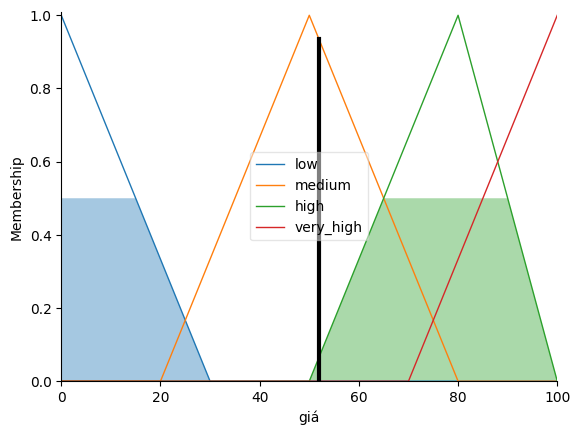

In [3]:
#2.11
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

QĐ = ctrl.Antecedent(np.arange(0, 21, 1), 'QĐ')
mc = ctrl.Antecedent(np.arange(0, 101, 1), 'mc')
TT = ctrl.Antecedent(np.arange(0, 11, 1), 'TT')
giá = ctrl.Consequent(np.arange(0, 101, 1), 'giá')

QĐ['short'] = fuzzy.trimf(QĐ.universe, [0, 0, 10])
QĐ['medium'] = fuzzy.trimf(QĐ.universe, [5, 10, 15])
QĐ['long'] = fuzzy.trimf(QĐ.universe, [10, 20, 20])

mc['low'] = fuzzy.trimf(mc.universe, [0, 0, 50])
mc['medium'] = fuzzy.trimf(mc.universe, [20, 50, 80])
mc['high'] = fuzzy.trimf(mc.universe, [50, 100, 100])

TT['good'] = fuzzy.trimf(TT.universe, [0, 0, 5])
TT['bad'] = fuzzy.trimf(TT.universe, [3, 7, 10])

giá['low'] = fuzzy.trimf(giá.universe, [0, 0, 30])
giá['medium'] = fuzzy.trimf(giá.universe, [20, 50, 80])
giá['high'] = fuzzy.trimf(giá.universe, [50, 80, 100])
giá['very_high'] = fuzzy.trimf(giá.universe, [70, 100, 100])

rule1 = ctrl.Rule(QĐ['short'] & mc['low'], giá['low'])
rule2 = ctrl.Rule(QĐ['medium'] & mc['medium'], giá['medium'])
rule3 = ctrl.Rule(mc['high'] | TT['bad'], giá['high'])
rule4 = ctrl.Rule(QĐ['long'] & mc['high'] & TT['bad'], giá['very_high'])

gia_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4])
gia = ctrl.ControlSystemSimulation(gia_ctrl)

gia.input['QĐ'] = float(input("nhập QĐ muốn đi:"))
gia.input['mc'] = float(input("nhu cầu:"))
gia.input['TT'] = float(input("mức độ xấu của thời tiết:"))
gia.compute()
print(f"Giá cước dự toán: {gia.output['giá']:.2f} VNĐ (nghìn)")
giá.view(sim=gia)

chấm điểm:5
khối lượng bán hàng:90
Biên lợi nhuận:95
sự kiện theo mùa:5
giảm giá của đối thủ cạnh tranh:80
Mức chiết khấu đề xuất: 1.75%


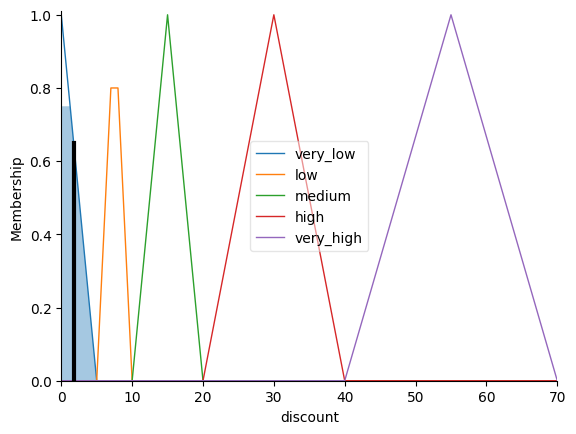

In [7]:
#2.12
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

rating = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'rating')
sales = ctrl.Antecedent(np.arange(0, 101, 1), 'sales')
profit = ctrl.Antecedent(np.arange(0, 101, 1), 'profit')
event = ctrl.Antecedent(np.arange(0, 11, 1), 'event')
competitor = ctrl.Antecedent(np.arange(0, 101, 1), 'competitor')
discount = ctrl.Consequent(np.arange(0, 71, 1), 'discount')
rating['low'] = fuzz.trimf(rating.universe, [0, 0, 4.0])
rating['medium'] = fuzz.trimf(rating.universe, [4.0, 4.25, 4.5])
rating['high'] = fuzz.trimf(rating.universe, [4.5, 5.0, 5.0])

discount['very_low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzz.trimf(discount.universe, [5, 7.5, 10])
discount['medium'] = fuzz.trimf(discount.universe, [10, 15, 20])
discount['high'] = fuzz.trimf(discount.universe, [20, 30, 40])
discount['very_high'] = fuzz.trimf(discount.universe, [40, 55, 70])
for var in [sales, profit, competitor]:
    var['low'] = fuzz.trimf(var.universe, [0, 0, 40])
    var['medium'] = fuzz.trimf(var.universe, [30, 50, 70])
    var['high'] = fuzz.trimf(var.universe, [60, 100, 100])
event['none'] = fuzz.trimf(event.universe, [0, 0, 2])
event['medium'] = fuzz.trimf(event.universe, [2, 5, 8])
event['high'] = fuzz.trimf(event.universe, [7, 10, 10])

rule1 = ctrl.Rule(rating['high'] & sales['high'] & profit['high'], discount['very_low'])
rule2 = ctrl.Rule(rating['low'] & sales['low'] & profit['high'], discount['high'])
rule3 = ctrl.Rule(event['high'] & competitor['high'], discount['very_high'])
rule4 = ctrl.Rule(rating['medium'] & sales['medium'] & profit['medium'], discount['medium'])
rule5 = ctrl.Rule(competitor['low'] & profit['low'] & sales['high'], discount['very_low'])
rule6 = ctrl.Rule(rating['low'] & event['none'], discount['medium'])
rule7 = ctrl.Rule(sales['low'] & profit['low'], discount['very_high'])

discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

discount_sim.input['rating'] = float(input("chấm điểm:"))
discount_sim.input['sales'] = float(input("khối lượng bán hàng:"))
discount_sim.input['profit'] = float(input("Biên lợi nhuận:"))
discount_sim.input['event'] = float(input("sự kiện theo mùa:"))
discount_sim.input['competitor'] = float(input("giảm giá của đối thủ cạnh tranh:"))
discount_sim.compute()

print(f"Mức chiết khấu đề xuất: {discount_sim.output['discount']:.2f}%")
discount.view(sim=discount_sim)

nhu cầu:80
áp lực cạnh tranh:70
Uy tín:4.5
Biên lợi nhuận:90
cầu theo mùa:85
Mức chiết khấu gợi ý cho sản phẩm: 42.83%


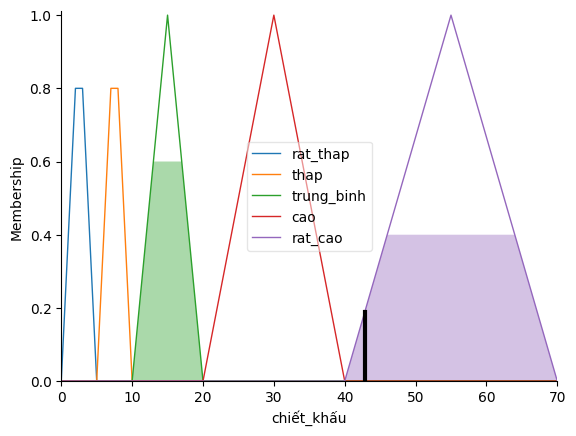

In [10]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

Nhu_cầu = ctrl.Antecedent(np.arange(0, 101, 1), 'Nhu_cầu')
Áp_lực_cạnh_tranh = ctrl.Antecedent(np.arange(0, 101, 1), 'Áp_lực_cạnh_tranh')
Uy_tín = ctrl.Antecedent(np.arange(0, 5.1, 0.1), 'Uy_tín')
Biên_lợi_nhuận = ctrl.Antecedent(np.arange(0, 101, 1), 'Biên_lợi_nhuận')
Cầu_theo_mùa = ctrl.Antecedent(np.arange(0, 101, 1), 'Cầu_theo_mùa')

chiết_khấu = ctrl.Consequent(np.arange(0, 71, 1), 'chiết_khấu')

for var in [Nhu_cầu, Áp_lực_cạnh_tranh, Biên_lợi_nhuận, Cầu_theo_mùa]:
    var['thap'] = fuzz.trimf(var.universe, [0, 0, 50])
    var['trung_binh'] = fuzz.trimf(var.universe, [0, 50, 100])
    var['cao'] = fuzz.trimf(var.universe, [50, 100, 100])

Uy_tín['thap'] = fuzz.trimf(Uy_tín.universe, [0, 0, 4.0])
Uy_tín['trung_binh'] = fuzz.trimf(Uy_tín.universe, [4.0, 4.25, 4.5])
Uy_tín['cao'] = fuzz.trimf(Uy_tín.universe, [4.5, 5.0, 5.0])

chiết_khấu['rat_thap'] = fuzz.trimf(chiết_khấu.universe, [0, 2.5, 5])
chiết_khấu['thap'] = fuzz.trimf(chiết_khấu.universe, [5, 7.5, 10])
chiết_khấu['trung_binh'] = fuzz.trimf(chiết_khấu.universe, [10, 15, 20])
chiết_khấu['cao'] = fuzz.trimf(chiết_khấu.universe, [20, 30, 40])
chiết_khấu['rat_cao'] = fuzz.trimf(chiết_khấu.universe, [40, 55, 70])

rule1 = ctrl.Rule(Nhu_cầu['cao'] & Áp_lực_cạnh_tranh['thap'] & Biên_lợi_nhuận['thap'], chiết_khấu['rat_thap'])
rule2 = ctrl.Rule(Nhu_cầu['thap'] & Áp_lực_cạnh_tranh['cao'] & Biên_lợi_nhuận['cao'], chiết_khấu['cao'])
rule3 = ctrl.Rule(Uy_tín['cao'] & Biên_lợi_nhuận['trung_binh'] & Cầu_theo_mùa['cao'], chiết_khấu['trung_binh'])
rule4 = ctrl.Rule(Áp_lực_cạnh_tranh['cao'] & Cầu_theo_mùa['cao'] & Biên_lợi_nhuận['cao'], chiết_khấu['rat_cao'])
rule5 = ctrl.Rule(Uy_tín['thap'] & Nhu_cầu['trung_binh'] & Biên_lợi_nhuận['thap'], chiết_khấu['trung_binh'])
rule6 = ctrl.Rule(Nhu_cầu['cao'] & Cầu_theo_mùa['thap'] & Áp_lực_cạnh_tranh['thap'], chiết_khấu['rat_thap'])

rule7 = ctrl.Rule(Biên_lợi_nhuận['cao'] & Cầu_theo_mùa['cao'] & Áp_lực_cạnh_tranh['trung_binh'], chiết_khấu['trung_binh'])
CK_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
CK_sim = ctrl.ControlSystemSimulation(CK_ctrl)
CK_sim.input['Nhu_cầu'] = float(input("nhu cầu:"))
CK_sim.input['Áp_lực_cạnh_tranh'] = float(input("áp lực cạnh tranh:"))
CK_sim.input['Uy_tín'] =  float(input("Uy tín:"))
CK_sim.input['Biên_lợi_nhuận'] =  float(input("Biên lợi nhuận:"))
CK_sim.input['Cầu_theo_mùa'] =   float(input("cầu theo mùa:"))
CK_sim.compute()
print(f"Mức chiết khấu gợi ý cho sản phẩm: {CK_sim.output['chiết_khấu']:.2f}%")
chiết_khấu.view(sim=CK_sim)

In [17]:
import numpy as np
import skfuzzy as fuzzy
from skfuzzy import control as ctrl

Mật_độ_đơn_hàng = ctrl.Antecedent(np.arange(0, 11, 1), 'Mật_độ_đơn_hàng')
Mức_độ_khẩn_cấp = ctrl.Antecedent(np.arange(0, 11, 1), 'Mức_độ_khẩn_cấp')
Tải_trọng_tài_xế = ctrl.Antecedent(np.arange(0, 11, 1), 'Tải_trọng_tài_xế')
Giao_thông = ctrl.Antecedent(np.arange(0, 11, 1), 'Giao_thông')
Lợi_nhuận = ctrl.Antecedent(np.arange(0, 11, 1), 'Lợi_nhuận')

Số_đơn_kết_hợp = ctrl.Consequent(np.arange(0, 11, 1), 'Số_đơn_kết_hợp')
Ưu_tiên_giao = ctrl.Consequent(np.arange(0, 11, 1), 'Ưu_tiên_giao')
names = ['Thap', 'TrungBinh', 'Cao']
for var in [Mật_độ_đơn_hàng, Mức_độ_khẩn_cấp, Tải_trọng_tài_xế, Giao_thông, Lợi_nhuận, Số_đơn_kết_hợp, Ưu_tiên_giao]:
    var['Thap'] = fuzz.trimf(var.universe, [0, 0, 5])
    var['TrungBinh'] = fuzz.trimf(var.universe, [0, 5, 10])
    var['Cao'] = fuzz.trimf(var.universe, [5, 10, 10])

rule1 = ctrl.Rule(Mật_độ_đơn_hàng['Cao'] & Tải_trọng_tài_xế['Thap'] & Giao_thông['Thap'], Số_đơn_kết_hợp['Cao'])
rule2 = ctrl.Rule(Mật_độ_đơn_hàng['TrungBinh'] & Giao_thông['Cao'] & Mức_độ_khẩn_cấp['TrungBinh'], Số_đơn_kết_hợp['TrungBinh'])
rule3 = ctrl.Rule(Tải_trọng_tài_xế['Cao'] & Mật_độ_đơn_hàng['Cao'] & Lợi_nhuận['TrungBinh'], Số_đơn_kết_hợp['TrungBinh'])

rule6 = ctrl.Rule(Mức_độ_khẩn_cấp['Cao'] & Lợi_nhuận['Cao'], Ưu_tiên_giao['Cao'])
rule7 = ctrl.Rule(Mức_độ_khẩn_cấp['TrungBinh'] & Giao_thông['TrungBinh'], Ưu_tiên_giao['TrungBinh'])
rule8 = ctrl.Rule(Mức_độ_khẩn_cấp['Thap'] & Mật_độ_đơn_hàng['Cao'] & Lợi_nhuận['Thap'], Ưu_tiên_giao['Thap'])

delivery_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule6, rule7, rule8])
delivery_sim = ctrl.ControlSystemSimulation(delivery_ctrl)

delivery_sim.input['Mật_độ_đơn_hàng'] = float(input("Mật độ đơn hàng:"))
delivery_sim.input['Mức_độ_khẩn_cấp'] = float(input("Mức độ khẩn cấp:"))
delivery_sim.input['Tải_trọng_tài_xế'] = float(input("Tải trọng tài xế:"))
delivery_sim.input['Giao_thông'] = float(input("Giao thông:"))
delivery_sim.input['Lợi_nhuận'] = float(input("Lợi nhuận:"))
delivery_sim.compute()
print(f"Số lượng đơn hàng nên kết hợp: {delivery_sim.output['Số_đơn_kết_hợp']:.2f}/10")
print(f"Mức độ ưu tiên giao hàng: {delivery_sim.output['Ưu_tiên_giao']:.2f}/10")

res_combine = delivery_sim.output['Số_đơn_kết_hợp']
res_priority = delivery_sim.output['Ưu_tiên_giao']

print("\nKết luận:")
if res_combine > 7:
    print("- Nên kết hợp NHIỀU đơn hàng (khoảng 5 đơn) để tối ưu chuyến đi.")
elif res_combine > 4:
    print("- Nên kết hợp một số đơn hàng vừa phải.")

if res_priority > 4 and res_priority < 7:
    print("- Thứ tự giao hàng ở mức TRUNG BÌNH.")

Mật độ đơn hàng:7
Mức độ khẩn cấp:3
Tải trọng tài xế:8
Giao thông:9
Lợi nhuận:10
Số lượng đơn hàng nên kết hợp: 5.00/10
Mức độ ưu tiên giao hàng: 5.00/10

Kết luận:
- Nên kết hợp một số đơn hàng vừa phải.
- Thứ tự giao hàng ở mức TRUNG BÌNH.
